# Exercise 12 – End-Point Binding Free Energy Calculations

## Learning goals

By the end of this exercise, you should be able to:

- Explain how binding free energies are related to configurational integrals.
- Estimate a standard binding free energy using an end-point approach.
- Decompose binding into interaction, ligand reorganization, and external entropy contributions.
- Understand the approximations and limitations of MM/GBSA-style methods.
- Interpret free-energy components in terms of structural ensembles.

Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. Log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 12-End-Point_BFE.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/12-End-Point_BFE.ipynb
```

Before running this notebook, you should have done the system setup (Exercise 7), equilibration (Exercise 8), and parallel tempering (Exercise 10). You need a sampling importance resampling (SIRS) trajectory generated in Exercise 11, but do not need to complete the whole exercise. If you generated a SIRS trajectory from incomplete parallel tempering calculations, you should go back and do SIRS again after (more) complete parallel tempering.

For this notebook, we will use the `shared` partition and `bpsim` conda environment.

```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 08:00:00 --interface lab --conda-env bpsim --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

The exercise will be graded based on submitting your answers to the questions after ```-->``` on Canvas.

## Part 0 - Installs and imports

In [1]:
import os
import numpy as np
import MDAnalysis as mda
from openmm import unit, Context, Platform, VerletIntegrator

## Part 1 – Conceptual background

### What problem are we solving?

In Exercise 11, you generated statistically meaningful ensembles of receptor–ligand configurations using enhanced sampling and sampling importance resampling (SIRS). In this exercise, we use those same ensembles to estimate a **standard binding free energy**.

We use an **end-point free energy method**: free energies are estimated from previously sampled configurations, and no new molecular dynamics simulations are performed.

### Statistical mechanics of binding

The standard binding free energy can be written as

$$ \Delta G^\circ_{bind} = - k_B T \ln \left( \frac{Z_{RL\Xi}}{Z_R Z_L Z_\Xi} \right) + \Delta G_{bound} $$

where:

- $Z_R$ and $Z_L$ are the configurational integrals of the unbound receptor and ligand,
- $Z_{RL\Xi}$ is the configurational integral of the bound complex restricted to the binding site $\Xi$,
- $\Delta G_{bound}$ is the standard-state correction, the free energy of restricting the ligand from bulk solvent to a bound state (ligand and receptor in proximity).

In this exercise, we will treat ensembles in the following ways:
- The bound ensemble is taken from the SIRS‑resampled low‑temperature trajectory.
- The unbound receptor is **approximated** using the same ensemble.
- The unbound ligand will be treated separately due to internal flexibility.

#### --> What assumptions are we making when we reuse bound receptor configurations to represent the unbound receptor?

### Decomposition of the binding free energy

Because there is limited configuration space overlap between the bound and unbound ensemble, we will use a thermodynamic cycle that includes:
- **$\Delta G_{\Psi}$**: receptor–ligand interaction free energy
- **$\Delta G_{\xi}$**: loss of external (translational and rotational) entropy when going from the bound state to the actual binding site
- **$\Delta G_{reorg}$**: ligand reorganization free energy  

<!-- 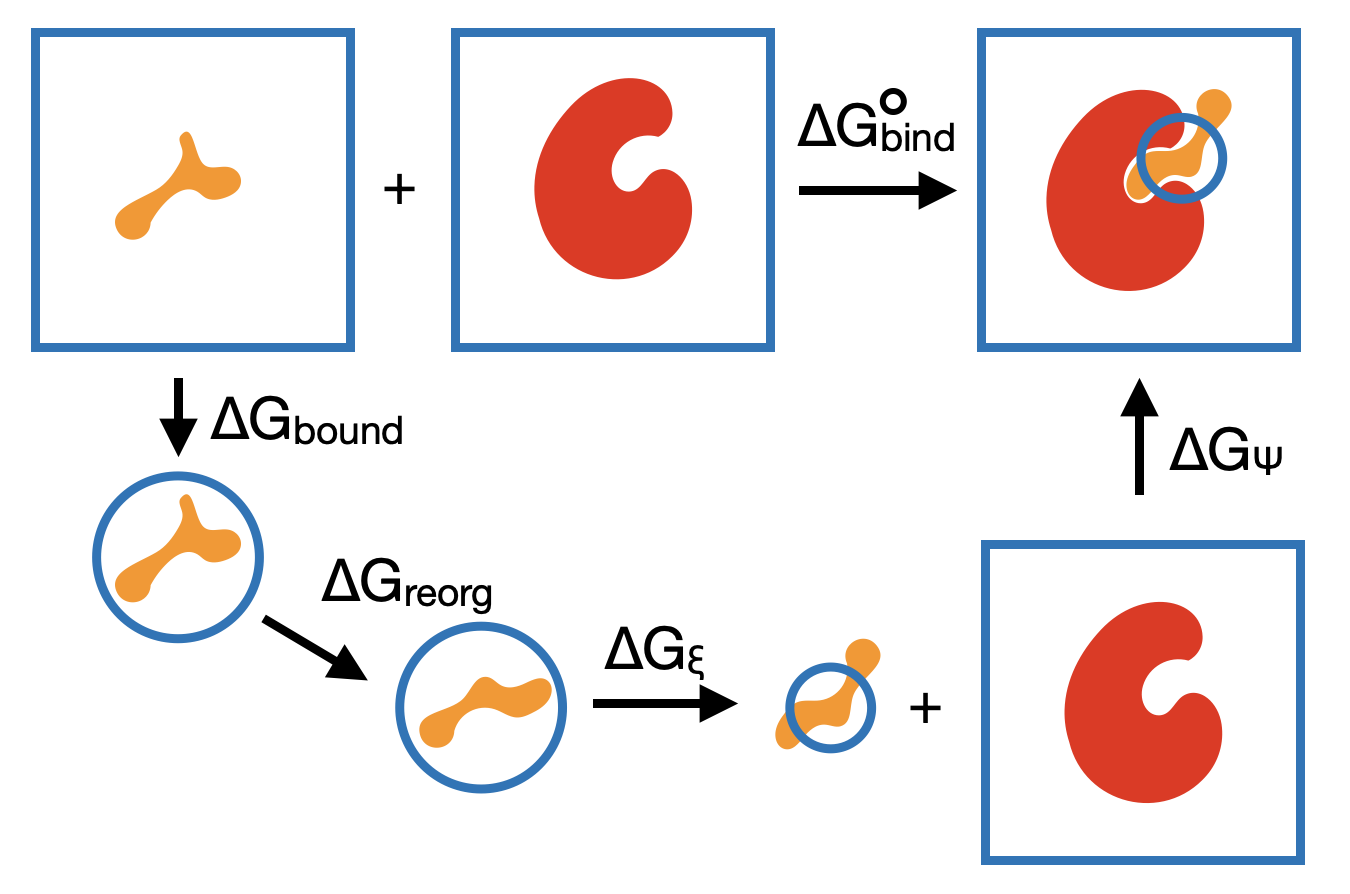 -->
<center>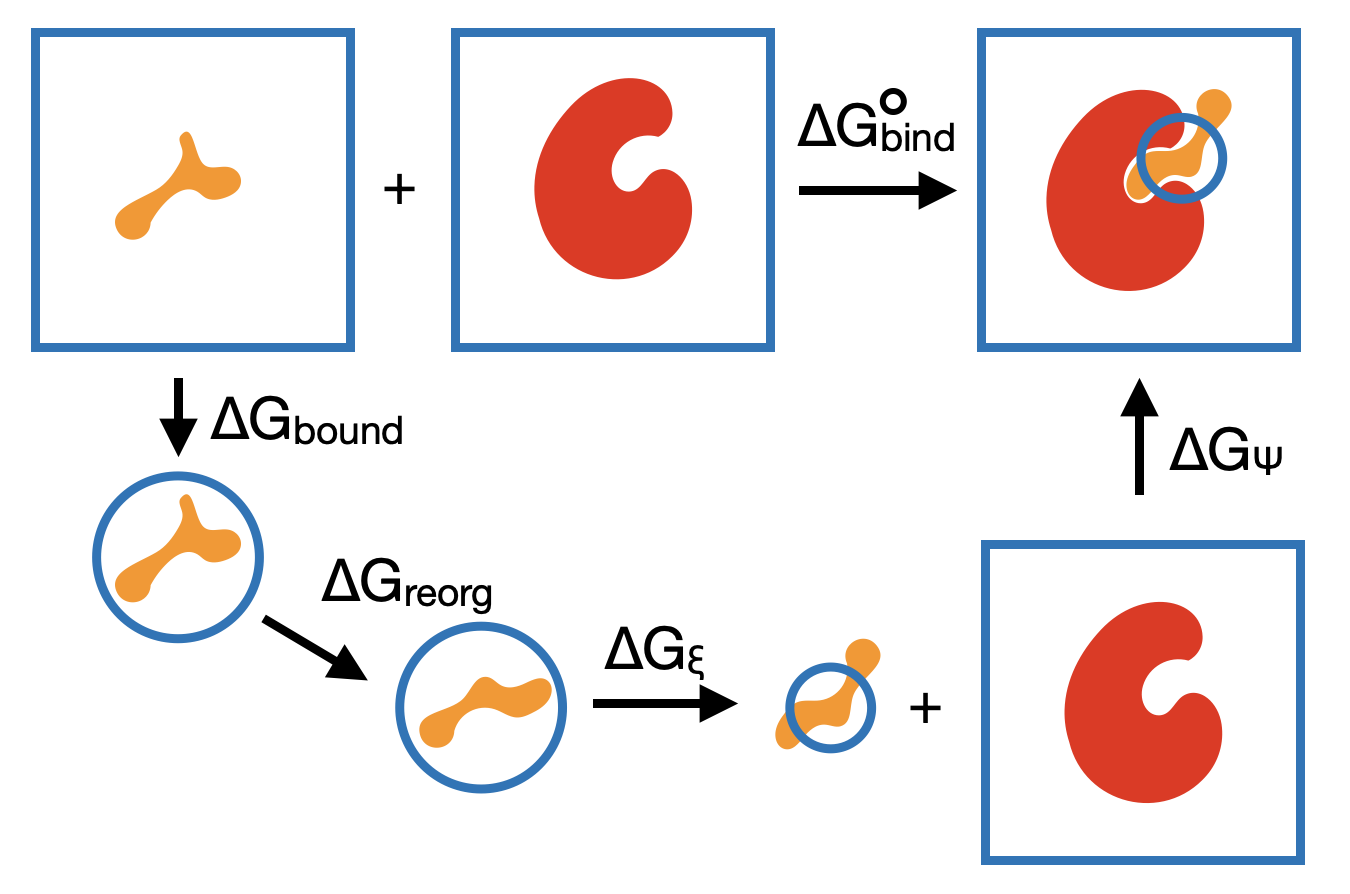</center>

Together, these terms add up to $- k_B T \ln \left( \frac{Z_{RL\Xi}}{Z_R Z_L Z_\Xi} \right)$ such that,

$$
\Delta G^\circ_{bind} = \Delta G_{\Psi} + \Delta G_{reorg} + \Delta G_{\xi} + \Delta G_{bound}
$$

We will calculate $\Delta G_{\Psi}$, $\Delta G_{reorg}$, and $\Delta G_{\xi}$ based on the simulated ensembles. On the other hand, $\Delta G_{bound}$ is a conventional standard‑state correction that enforces a 1 M reference concentration.

## Part 2 – Interaction energy

The interaction energy is the core of the end-point free energy method known as the Molecular Mechanics Generalized Born Surface Area (MM/GBSA) method. This name describes the approach used to compute the potential energy of the system. Generalized Born Surface Area refers to the implicit solvent model based on Generalized Born electrostatics and a cavity formation term proportional to the Surface Area.

For each configuration in the bound ensemble, the interaction energy is defined as

$$
\Psi = U_{RL} - U_R - U_L,
$$

where all energies are evaluated using the same force-field parameters and solvent model.

Modify the cell below to your system and ligand SMILES string.

In [2]:
MM_system = 'MSX-2'
ligand_smiles = 'C#CN3C(=O)N(CCCO)C1=C([N](C(=N1)C=CC2=CC(=CC=C2)O[H])C)C3=O'

### Create OpenMM-derived PDBs

In [3]:
# Load OpenMM system and topology of the complex with water and membrane
ex07_dir = os.path.expanduser(f'~/exercises/07/systems')
from openmm import XmlSerializer
with open(os.path.join(ex07_dir, f'{MM_system}.xml')) as f:
    omm_system = XmlSerializer.deserialize(f.read())

from openmm.app import PDBFile
pdb = PDBFile(os.path.join(ex07_dir, f'{MM_system}.pdb'))
omm_topology  = pdb.topology
omm_positions = pdb.positions

# Create separate topologies for the complex, receptor, and ligand without water and membrane
water_resnames = {"HOH", "WAT", "TIP3", "NA", "CL"}
membrane_resnames = {"POP", "POPC", "POPE", "POPG", "CHOL"}
ligand_resname = "UNK"

from openmm.app import Modeller

topologies = {}
# Create a topology for the complex without water and membrane
topologies['RL'] = Modeller(omm_topology, omm_positions)
topologies['RL'].delete([atom for atom in topologies['RL'].topology.atoms()
    if atom.residue.name in water_resnames
    or atom.residue.name in membrane_resnames
])

# Create a topology for the receptor alone
topologies['R'] = Modeller(omm_topology, omm_positions)
topologies['R'].delete([atom for atom in topologies['R'].topology.atoms()
    if atom.residue.name == ligand_resname or 
    atom.residue.name in water_resnames
    or atom.residue.name in membrane_resnames
])

# Create a topology for the ligand alone
topologies['L'] = Modeller(omm_topology, omm_positions)
topologies['L'].delete([atom for atom in topologies['L'].topology.atoms()
    if atom.residue.name != ligand_resname
])

! mkdir -p 12

# Write PDB files of each
from openmm.app import PDBFile

PDBFile.writeFile(
    topologies['RL'].topology,
    topologies['RL'].positions,
    open("12/complex.pdb", "w")
)

PDBFile.writeFile(
    topologies['R'].topology,
    topologies['R'].positions,
    open("12/receptor.pdb", "w")
)

PDBFile.writeFile(
    topologies['L'].topology,
    topologies['L'].positions,
    open("12/ligand.pdb", "w")
)

with open("12/ligand.pdb") as f:
    pdb_lines = f.readlines()

with open("12/ligand_LIG.pdb", "w") as f:
    for line in pdb_lines:
        if line.startswith(("ATOM", "HETATM")):
            # Replace residue name UNK → LIG (columns 18–20)
            line = line[:17] + "LIG" + line[20:]
        f.write(line)
        
with open("12/complex.pdb") as f:
    pdb_lines = f.readlines()

with open("12/complex_LIG.pdb", "w") as f:
    for line in pdb_lines:
        if line.startswith(("ATOM", "HETATM")):
            line = line[:17] + ("LIG" if line[17:20] == "UNK" else line[17:20]) + line[20:]
        f.write(line)

In [4]:
%%bash
cd 12
pdb4amber -i complex_LIG.pdb  -o complex_amber.pdb
pdb4amber -i receptor.pdb -o receptor_amber.pdb
pdb4amber -i ligand_LIG.pdb   -o ligand_amber.pdb
cd ..


Summary of pdb4amber for: complex_LIG.pdb

----------Chains
The following (original) chains have been found:
A
B

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
None
-----------Non-standard-resnames
LIG

---------- Missing heavy atom(s)

None

Summary of pdb4amber for: receptor.pdb

----------Chains
The following (original) chains have been found:
A

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
None
-----------Non-standard-resnames


---------- Missing heavy atom(s)

None

Summary of pdb4amber for: ligand_LIG.pdb

----------Chains
The following (original) chains have been found:
A

---------- Alternate Locations (Original Residues!))

The following residues had alternate locations:
None
-----------Non-standard-resnames
LIG

---------- Missing heavy atom(s)

None


### Step 2 — Parameterize systems with AMBER tleap

First we will prepare ligand GAFF files (mol2 + frcmod).

In [5]:
%%bash
cd 12
antechamber -i ligand_amber.pdb \
             -fi pdb \
             -o ligand.mol2 \
             -fo mol2 \
             -c bcc \
             -rn LIG \
             -s 2

parmchk2 -i ligand.mol2 -f mol2 -o ligand.frcmod
cd ..


Welcome to antechamber 22.0: molecular input file processor.

Info: acdoctor mode is on: check and diagnose problems in the input file.
Info: The atom type is set to gaff; the options available to the -at flag are
      gaff, gaff2, amber, bcc, and sybyl.

-- Check Format for pdb File --
   Status: pass
Info: Determining atomic numbers from atomic symbols which are case sensitive.
-- Check Unusual Elements --
   Status: pass
-- Check Open Valences --
   Status: pass
-- Check Geometry --
      for those bonded   
      for those not bonded   
   Status: pass
-- Check Weird Bonds --
   Status: pass
-- Check Number of Units --
   Status: pass
acdoctor mode has completed checking the input file.

Running: /Users/dminh/anaconda3/envs/bpsim/bin/bondtype -j full -i ANTECHAMBER_BOND_TYPE.AC0 -o ANTECHAMBER_BOND_TYPE.AC -f ac

Running: /Users/dminh/anaconda3/envs/bpsim/bin/atomtype -i ANTECHAMBER_AC.AC0 -o ANTECHAMBER_AC.AC -p gaff
Info: Total number of electrons: 192; net charge: 0

Running: 

Next we will generate AMBER topology files

In [6]:
%%bash
cd 12
cat > leap.in << 'EOF'
source leaprc.protein.ff14SB
source leaprc.gaff2

# Load ligand first
LIG = loadmol2 ligand.mol2
loadamberparams ligand.frcmod

# Load cleaned structures
COM = loadpdb complex_amber.pdb
REC = loadpdb receptor_amber.pdb

# Save parameters
saveamberparm COM complex.prmtop complex.inpcrd
saveamberparm REC receptor.prmtop receptor.inpcrd
saveamberparm LIG ligand.prmtop ligand.inpcrd

quit
EOF

tleap -f leap.in
cd ..

-I: Adding /Users/dminh/anaconda3/envs/bpsim/dat/leap/prep to search path.
-I: Adding /Users/dminh/anaconda3/envs/bpsim/dat/leap/lib to search path.
-I: Adding /Users/dminh/anaconda3/envs/bpsim/dat/leap/parm to search path.
-I: Adding /Users/dminh/anaconda3/envs/bpsim/dat/leap/cmd to search path.
-f: Source leap.in.

Welcome to LEaP!
(no leaprc in search path)
Sourcing: ./leap.in
----- Source: /Users/dminh/anaconda3/envs/bpsim/dat/leap/cmd/leaprc.protein.ff14SB
----- Source of /Users/dminh/anaconda3/envs/bpsim/dat/leap/cmd/leaprc.protein.ff14SB done
Log file: ./leap.log
Loading parameters: /Users/dminh/anaconda3/envs/bpsim/dat/leap/parm/parm10.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA
Loading parameters: /Users/dminh/anaconda3/envs/bpsim/dat/leap/parm/frcmod.ff14SB
Reading force field modification type file (frcmod)
Reading title:
ff14SB protein backbone and sidechain parameters
Loading library: /Users/dminh/anaconda3/envs/bpsim/dat/leap/lib/amino12.lib


### Load AMBER topologies in OpenMM and evaluate MM/GBSA interaction energies

In [7]:
from openmm.app import AmberPrmtopFile, NoCutoff, OBC2
from openmm import unit, Context, VerletIntegrator, Platform

prmtops = {
    'R': AmberPrmtopFile('12/receptor.prmtop'),
    'L': AmberPrmtopFile('12/ligand.prmtop'),
    'RL': AmberPrmtopFile('12/complex.prmtop')
}

systems = {}

for species in ['R', 'L', 'RL']:
    systems[species] = prmtops[species].createSystem(
        nonbondedMethod=NoCutoff,                      # Required for GB
        implicitSolvent=OBC2,                           # GB-OBC2 (igb=5)
        implicitSolventSaltConc=0.150 * unit.mole/unit.liter,
        constraints=None
    )

platform = Platform.getPlatformByName("CPU")

contexts = {}
integrators = {}

for species in ['R', 'L', 'RL']:
    integrators[species] = VerletIntegrator(1.0 * unit.femtoseconds)
    contexts[species] = Context(
        systems[species],
        integrators[species],
        platform
    )

/Users/dminh/anaconda3/envs/bpsim/lib/python3.12/site-packages/openmm/app/internal/amber_file_parser.py:1169: UserWarning: Non-optimal GB parameters detected for GB model OBC2
  warnings.warn(


In this exercise, we analyze a pre-aligned molecular dynamics (MD) trajectory generated in 11-SIRS.py.

In [8]:
import os
import numpy as np

if not os.path.isdir('12'):
    ! mkdir -p 12
psi_file = f"12/Psi_{MM_system}.npy"

if os.path.exists(psi_file):
    print(f"Loading previously saved interaction energies from '{psi_file}'")
    Psi = np.load(psi_file)
else:
    print("Ψ not found on disk — computing interaction energies")

    ex11_dir = os.path.expanduser(f'~/exercises/11/{MM_system}')
    u = mda.Universe(os.path.join(ex11_dir, f'{MM_system}_SIRS_reference.pdb'), \
                     os.path.join(ex11_dir, f'{MM_system}_SIRS_aligned.dcd'))
    print(f'The number of frames is {len(u.trajectory)}')
    
    index_map = {}
    index_map['R'] = u.select_atoms("protein").indices
    index_map['L'] = u.select_atoms("resname UNK").indices
    index_map['RL'] = u.select_atoms("protein or resname UNK").indices    

    Psi = np.zeros(len(u.trajectory))

    for i, ts in enumerate(u.trajectory):

        xyz = u.atoms.positions * unit.angstrom

        contexts['RL'].setPositions(xyz[index_map['RL']])
        contexts['R'].setPositions(xyz[index_map['R']])
        contexts['L'].setPositions(xyz[index_map['L']])

        U_RL = contexts['RL'].getState(getEnergy=True).getPotentialEnergy()
        U_R  = contexts['R'].getState(getEnergy=True).getPotentialEnergy()
        U_L  = contexts['L'].getState(getEnergy=True).getPotentialEnergy()

        Psi[i] = (U_RL - U_R - U_L).value_in_unit(
            unit.kilocalorie_per_mole
        )

    np.save(psi_file, Psi)
    print(f"Saved interaction energies Ψ to '{psi_file}'")

print(f"Ψ statistics (kcal/mol):")
print(f"  Mean: {Psi.mean():.2f}")
print(f"  Std:  {Psi.std():.2f}")

Ψ not found on disk — computing interaction energies
The number of frames is 681


/Users/dminh/anaconda3/envs/bpsim/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Saved interaction energies Ψ to '12/Psi_MSX-2.npy'
Ψ statistics (kcal/mol):
  Mean: 209.54
  Std:  147.04


#### --> Why is it possible, in principle, to compute a binding free energy from previously sampled configurations without running new simulations?

### Statistical estimators
Several estimators of the interaction free energy are commonly used:

- The mean interaction energy,
$$\Delta G_{\Psi, mean} = \langle \Psi \rangle.$$
The original MM/GBSA free energy estimate is based on $\Delta G_{\Psi, mean}$ and does not account for $\Delta G_{bound}$, $\Delta G_{\xi}$, or $\Delta G_{reorg}$.
- The second-order cumulant expansion, which includes an approximate entropy, 
$$
\Delta G_{\Psi, c2} =
\langle \Psi \rangle - \frac{\beta}{2}\,\mathrm{Var}(\Psi)
$$
- The exponential average, as initially introduced by Zwanzig, is,
$$
\Delta G_{\Psi, EXP} = - k_B T \ln \langle e^{- \beta \Psi} \rangle
$$

$\Delta G_{\Psi, EXP}$ is theoretically valid, but can be numerically unstable. $\Delta G_{\Psi, mean}$ and $\Delta G_{\Psi, c2}$ are more numerically stable estimators, but may be biased.

ΔG_Ψ estimators (kJ/mol)
  Mean estimator:         209.54
  Cumulant estimator:   -4151.21
  Exponential estimator:   33.98


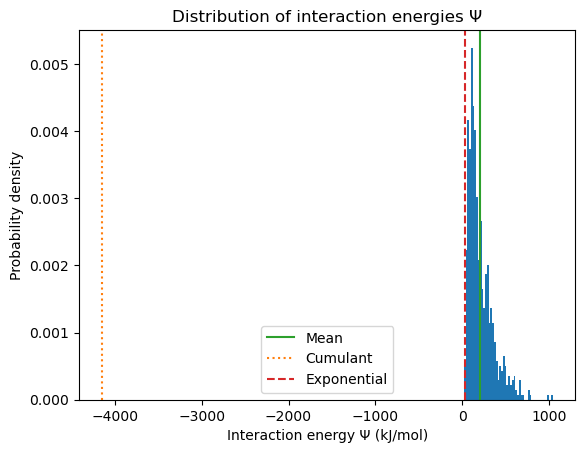

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure Psi is a NumPy array
Psi = np.asarray(Psi)

kB = 0.008314462618  # kJ/mol/K
T  = 298.15          # K
beta = 1.0 / (kB * T)

# -----------------------------
# Estimators
# -----------------------------

# 1. Mean interaction energy
DeltaG_mean = Psi.mean()

# 2. Second-order cumulant approximation
DeltaG_cumulant = Psi.mean() - 0.5 * beta * Psi.var()

# 3. Exponential (Zwanzig) estimator
DeltaG_exp = -1.0 / beta * np.log(np.mean(np.exp(-beta * Psi)))

print("ΔG_Ψ estimators (kJ/mol)")
print(f"  Mean estimator:       {DeltaG_mean:8.2f}")
print(f"  Cumulant estimator:   {DeltaG_cumulant:8.2f}")
print(f"  Exponential estimator:{DeltaG_exp:8.2f}")

# -----------------------------
# Plot histogram with estimators
# -----------------------------

plt.figure()
plt.hist(Psi, bins=50, density=True)

plt.axvline(DeltaG_mean, color="tab:green", linestyle="-", label="Mean")
plt.axvline(DeltaG_cumulant, color="tab:orange", linestyle=":", label="Cumulant")
plt.axvline(DeltaG_exp, color="tab:red", linestyle="--", label="Exponential")

plt.xlabel("Interaction energy Ψ (kJ/mol)")
plt.ylabel("Probability density")
plt.title("Distribution of interaction energies Ψ")
plt.legend()

plt.show()

#### --> Why do these estimators give different numerical results when applied to the same set of interaction energies?

## Part 3 – Ligand reorganization free energy

Ligands often populate many internal conformations in solution, but only a subset are compatible with binding. The **ligand reorganization free energy** quantifies the cost of restricting the ligand to binding‑competent conformations. It is primarily entropic.

#### --> Would the ligand reorganization free energy be larger for a flexible ligand or a rigid ligand? Why?

In this section we will analyze ligand conformational motions using dihedral PCA. However, we won't explicitly calculate it.

### 3.1 Gas‑phase ligand simulation

Before performing dihedral PCA, we generate a short gas‑phase trajectory of the ligand. This trajectory samples the ligand’s intrinsic conformational flexibility in the absence of protein interactions and solvent, providing a reference ensemble for reorganization analysis.

In [ ]:
from openmm import LangevinIntegrator
from openmm.app import Simulation
from openmm.app import DCDReporter, StateDataReporter
import sys

ligand_traj_FN = f"12/apo_{MM_system}.dcd"
if not os.path.isfile(ligand_traj_FN):
    integrator = LangevinIntegrator(300 * unit.kelvin, 1.0 / unit.picosecond, 2.0 * unit.femtosecond)
    simulation = Simulation(topologies['L'].topology, systems['L'], integrator)
    
    ex11_dir = os.path.expanduser(f'~/exercises/11/{MM_system}')
    u = mda.Universe(os.path.join(ex11_dir, f'{MM_system}_SIRS_reference.pdb'), \
                     os.path.join(ex11_dir, f'{MM_system}_SIRS_aligned.dcd'))

    # Write the holo trajectory
    ligand_sel = u.select_atoms("resname UNK")
    with mda.Writer(f'12/holo_{MM_system}.dcd', ligand_sel.n_atoms) as W:
        for ts in u.trajectory:
            W.write(ligand_sel)
    # Write the pdb file of the ligand alone
    with mda.Writer(f"12/{MM_system}.pdb", ligand_sel.n_atoms) as W:
        W.write(ligand_sel)            

    # Set the ligand position for starting the apo trajectory
    index_map['L'] = ligand_sel.indices
    xyz = u.atoms.positions * unit.angstrom
    simulation.context.setPositions(xyz[index_map['L']])
    
    nsteps = 500000  # 500000 * 2 fs = 1 ns
    simulation.reporters.append(DCDReporter(ligand_traj_FN, 5000))
    simulation.reporters.append(
        StateDataReporter(sys.stdout, 5000, step=True, temperature=True, potentialEnergy=True)
    )
    
    print("Running gas-phase ligand dynamics...")
    simulation.step(nsteps)
    print("Simulation complete.")

### 3.2 Dihedral PCA of the bound ensemble

Ligand conformational fluctuations are high‑dimensional. To identify the dominant internal motions, we perform PCA on ligand dihedral angles.

Because dihedrals are periodic variables, each angle is represented using its sine and cosine before PCA is applied.

In [ ]:
u = mda.Universe(f'12/{MM_system}.pdb', [f'12/apo_{MM_system}.dcd', f'12/holo_{MM_system}.dcd'])
R = BAT(u.atoms)
R.run()
bat = R.results.bat.copy()
tors = bat[:, -len(R._torsion_XYZ_inds):]
eu_tors = np.concatenate([np.cos(tors), np.sin(tors)], axis=1)

from sklearn.decomposition import PCA
pca = PCA(2)
reduced_tors = pca.fit_transform(eu_tors)
pca_weights = pca.components_

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    reduced_tors[:100, 0], reduced_tors[:100, 1],
    s=8, alpha=0.6, label="Apo (gas phase)", color="tab:blue"
)

plt.scatter(
    reduced_tors[100:, 0], reduced_tors[100:, 1],
    s=8, alpha=0.6, label="Holo (bound)", color="tab:red"
)

plt.xlabel("PC1 (dihedral)")
plt.ylabel("PC2 (dihedral)")
plt.title("Ligand dihedral PCA (apo vs holo)")
plt.legend()
plt.tight_layout()
plt.show()

#### --> Do the apo and holo ligand occupy the same configuration space?

## Part 4 – External entropy and the standard state

Binding restricts the ligand’s translational and rotational degrees of freedom, giving rise to an **external entropy penalty**.

In this exercise, we estimate this contribution **directly from the observed bound ensemble**. To do this, we compute the ligand center‑of‑mass (COM) relative to the protein COM over the bound (holo) trajectory.

#### --> Why is a external entropy correction required even when the bound state is explicitly defined?

In [ ]:
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

ex11_dir = os.path.expanduser(f'~/exercises/11/{MM_system}')
u = mda.Universe(os.path.join(ex11_dir, f'{MM_system}_SIRS_reference.pdb'), \
                 os.path.join(ex11_dir, f'{MM_system}_SIRS_aligned.dcd'))

protein = u.select_atoms("protein")
ligand  = u.select_atoms("resname UNK")

print("Protein atoms:", protein.n_atoms)
print("Ligand atoms :", ligand.n_atoms)
print("Holo frames  :", len(u.trajectory))

# Collect relative COM positions
rel_com = []

for ts in u.trajectory:
    r_lig = ligand.center_of_mass()
    r_pro = protein.center_of_mass()
    rel_com.append(r_lig - r_pro)

rel_com = np.array(rel_com)  # shape: (n_frames, 3)

print("Relative COM array shape:", rel_com.shape)

# Ranges along x, y, z
x_range = rel_com[:,0].max() - rel_com[:,0].min()
y_range = rel_com[:,1].max() - rel_com[:,1].min()
z_range = rel_com[:,2].max() - rel_com[:,2].min()

print("Translational ranges (Å):")
print(f"  Δx = {x_range:.2f}")
print(f"  Δy = {y_range:.2f}")
print(f"  Δz = {z_range:.2f}")

V_bind = x_range * y_range * z_range

print(f"Estimated binding‑site volume V_bind ≈ {V_bind:.1f} Å³")
print(f"For comparison the volume of a sphere is 5 A radius is {4/3*np.pi*5**3:.1f} Å³")

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

# Scatter ligand COM positions
ax.scatter(
    rel_com[:, 0],
    rel_com[:, 1],
    rel_com[:, 2],
    s=5,
    alpha=0.4,
    color="tab:blue"
)

# Compute bounds
xmin, xmax = rel_com[:, 0].min(), rel_com[:, 0].max()
ymin, ymax = rel_com[:, 1].min(), rel_com[:, 1].max()
zmin, zmax = rel_com[:, 2].min(), rel_com[:, 2].max()

# Define box corners
corners = np.array([
    [xmin, ymin, zmin],
    [xmax, ymin, zmin],
    [xmax, ymax, zmin],
    [xmin, ymax, zmin],
    [xmin, ymin, zmax],
    [xmax, ymin, zmax],
    [xmax, ymax, zmax],
    [xmin, ymax, zmax],
])

# Define box edges (pairs of corner indices)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),  # bottom face
    (4, 5), (5, 6), (6, 7), (7, 4),  # top face
    (0, 4), (1, 5), (2, 6), (3, 7)   # vertical edges
]

# Draw wireframe box
for i, j in edges:
    ax.plot(
        [corners[i, 0], corners[j, 0]],
        [corners[i, 1], corners[j, 1]],
        [corners[i, 2], corners[j, 2]],
        color="black",
        linewidth=1.5
    )

ax.set_xlabel("Δx (Å)")
ax.set_ylabel("Δy (Å)")
ax.set_zlabel("Δz (Å)")
ax.set_title("Ligand translational range in binding site")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Constants
kB = 0.008314462618   # kJ/mol/K
T  = 298.15           # K
kJ_to_kcal = 1.0 / 4.184

# Volumes (Å^3)
V_site = (4.0 / 3.0) * np.pi * (5.0 ** 3)  # 5 Å radius sphere
V_std  = 1660.0                            # 1 M standard-state volume

# Compute free energies (kJ/mol)
DeltaG_site_kJ = -kB * T * np.log(V_site / V_std)
DeltaG_xi_kJ   = -kB * T * np.log(V_bind / V_site)

# Convert to kcal/mol
DeltaG_site = DeltaG_site_kJ * kJ_to_kcal
DeltaG_xi   = DeltaG_xi_kJ   * kJ_to_kcal
DeltaG_trans = DeltaG_site + DeltaG_xi

print(f"V_site = {V_site:.1f} Å³")
print(f"V_bind = {V_bind:.1f} Å³\n")

print("Translational free-energy contributions (kcal/mol)")
print(f"  ΔG_site  = {DeltaG_site:6.2f}")
print(f"  ΔG_ξ     = {DeltaG_xi:6.2f}")

Typical binding‑site volumes of a few hundred Å³ correspond to translational entropy penalties of a few kcal/mol, consistent with physical expectations.

## Part 5 – Final binding free energy and interpretation

The final estimate of the standard binding free energy (excluding ligand reorganization) is

$$
\Delta G^\circ_{bind} = \Delta G_{\xi} + \Delta G_{\Psi} + \Delta G_{bound}
$$

Its accuracy is limited by,

- finite sampling,
- the quality of the force field,
- approximations used in each contribution.

#### --> What are some ways to improve the accuracy of an end‑point binding free energy calculation?

In [ ]:
import numpy as np

# Constants
kB = 0.008314462618   # kJ/mol/K
T  = 298.15           # K
beta = 1.0 / (kB * T)
kJ_to_kcal = 1.0 / 4.184

# --- Interaction free energy: second-order cumulant ---
DeltaG_Psi_kJ = Psi.mean() - 0.5 * beta * Psi.var()
DeltaG_Psi = DeltaG_Psi_kJ * kJ_to_kcal  # convert to kcal/mol

# --- Assemble binding free energy (ignoring reorganization) ---
DeltaG_bind = DeltaG_Psi + DeltaG_site + DeltaG_xi

# --- Report ---
print("Part 5 — Binding free energy components (kcal/mol)")
print(f"  ΔGΨ (cumulant) = {DeltaG_Psi:7.2f}")
print(f"  ΔG_site        = {DeltaG_site:7.2f}")
print(f"  ΔG_ξ           = {DeltaG_xi:7.2f}")
print(f"  -----------------------------")
print(f"  ΔG_bind        = {DeltaG_bind:7.2f}")